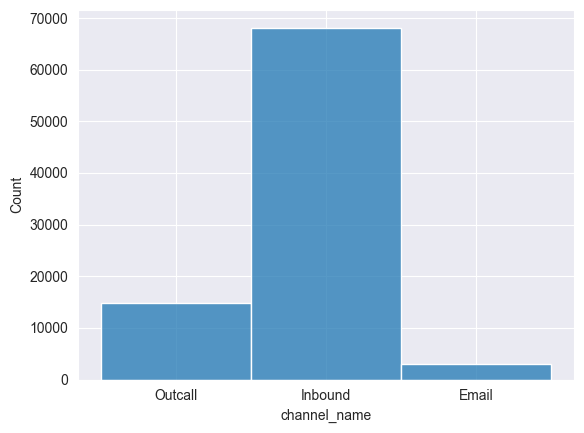

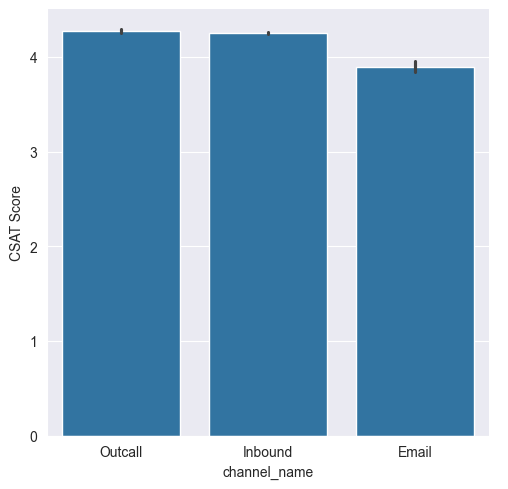

In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score

CS_data = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML5.3%20categorical%20features/data/Customer_support_data.csv', index_col=0)

sns.histplot(data=CS_data, x='channel_name')
plt.show()
CS_data.channel_name.value_counts()

sns.catplot(data=CS_data, x='channel_name', y='CSAT Score', kind='bar')
plt.show()

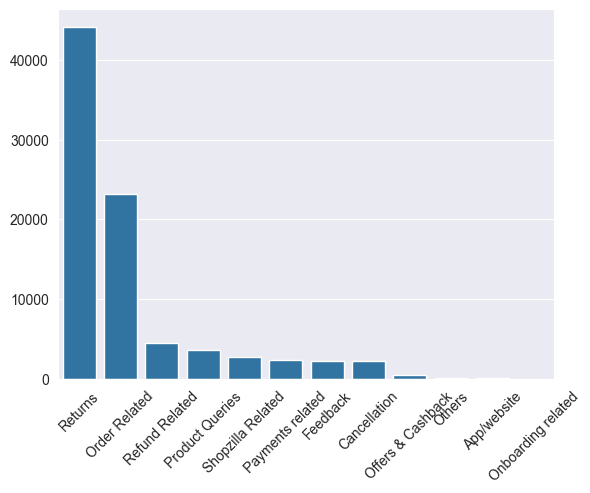

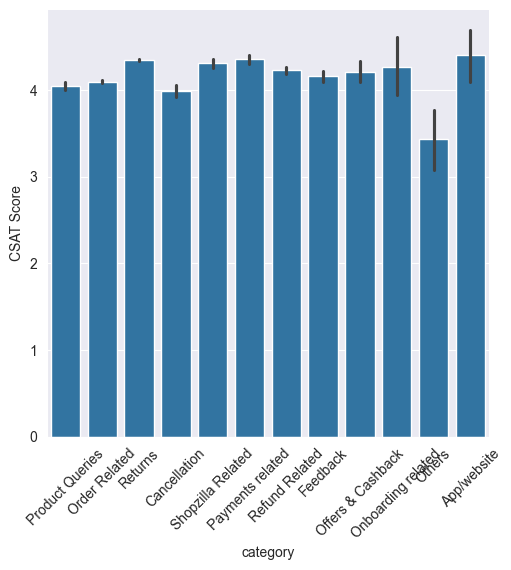

In [58]:
count = CS_data.category.value_counts()
sns.barplot(x=count.index.values, y=count.values)
plt.xticks(rotation=45)
plt.show()

sns.catplot(data=CS_data, x='category', y='CSAT Score', kind='bar')
plt.xticks(rotation=45)
plt.show()

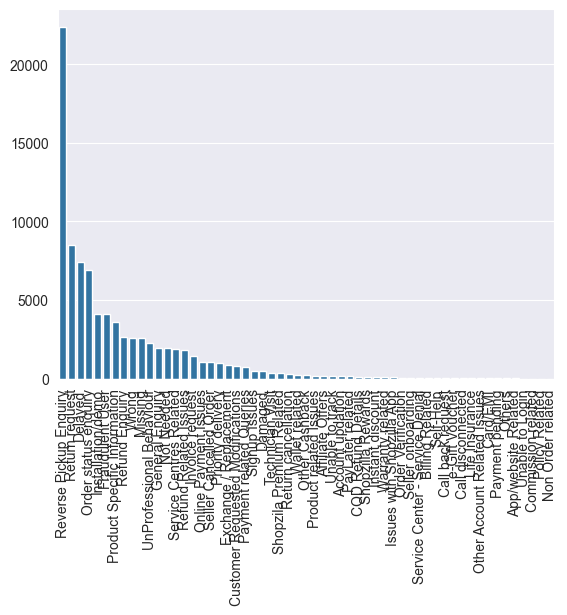

Sub-category
Reverse Pickup Enquiry              22389
Return request                       8523
Delayed                              7388
Order status enquiry                 6922
Installation/demo                    4116
Fraudulent User                      4108
Product Specific Information         3589
Refund Enquiry                       2665
Wrong                                2597
Missing                              2556
UnProfessional Behaviour             2294
General Enquiry                      1945
Not Needed                           1920
Service Centres Related              1875
Refund Related Issues                1800
Invoice request                      1465
Online Payment Issues                1079
Seller Cancelled Order               1059
Priority delivery                     972
Exchange / Replacement                896
Customer Requested Modifications      805
Payment related Queries               743
Signup Issues                         489
Damaged              

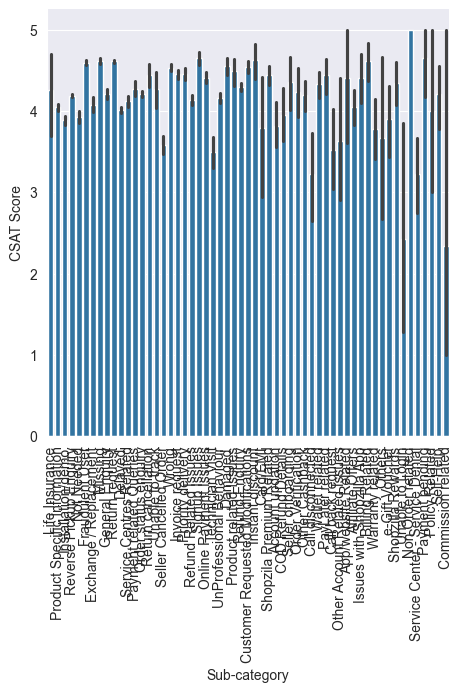

In [59]:
count = CS_data['Sub-category'].value_counts()
sns.barplot(x=count.index.values, y=count.values)
plt.xticks(rotation=90)
plt.show()

print(CS_data['Sub-category'].value_counts())

sns.catplot(data=CS_data, x='Sub-category', y='CSAT Score', kind='bar')
plt.xticks(rotation=90)
plt.show()

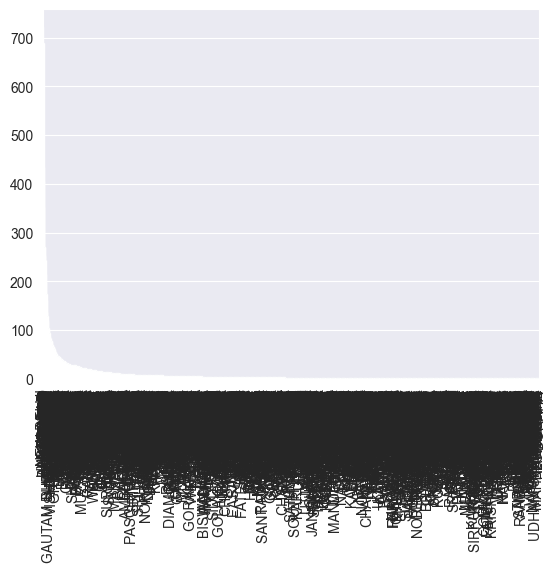

In [60]:
count = CS_data['Customer_City'].value_counts()
sns.barplot(x=count.index.values, y=count.values)
plt.xticks(rotation=90)
plt.show()


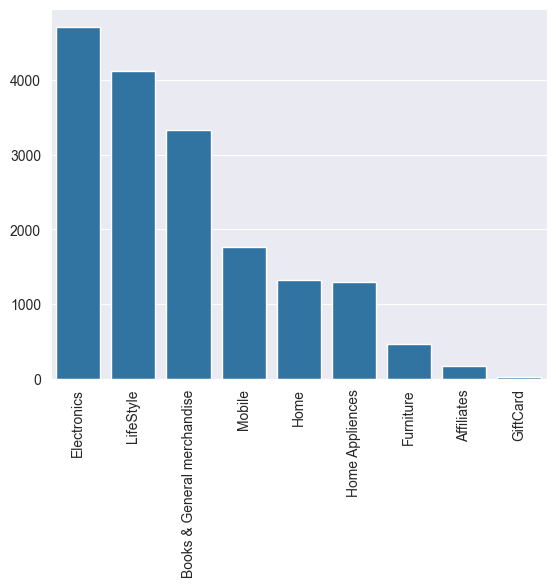

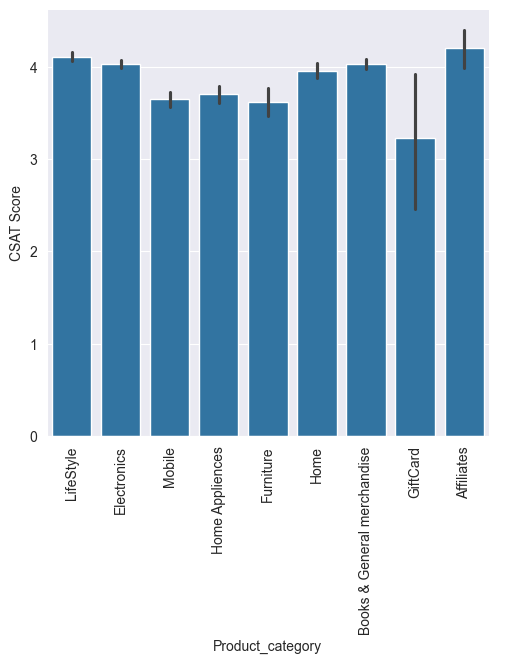

In [61]:
count = CS_data['Product_category'].value_counts()
sns.barplot(x=count.index.values, y=count.values)
plt.xticks(rotation=90)
plt.show()

sns.catplot(data=CS_data, x='Product_category', y='CSAT Score', kind='bar')
plt.xticks(rotation=90)
plt.show()


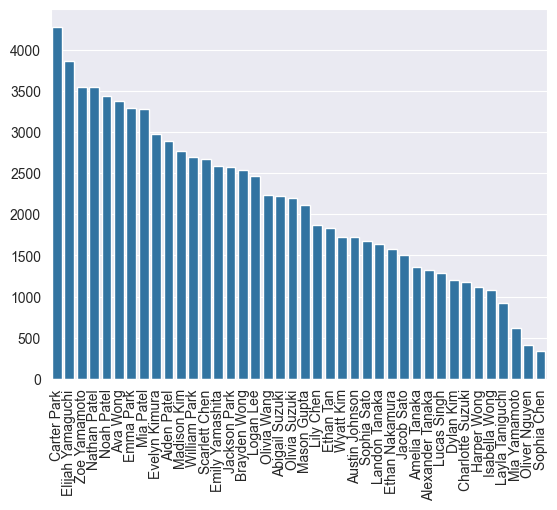

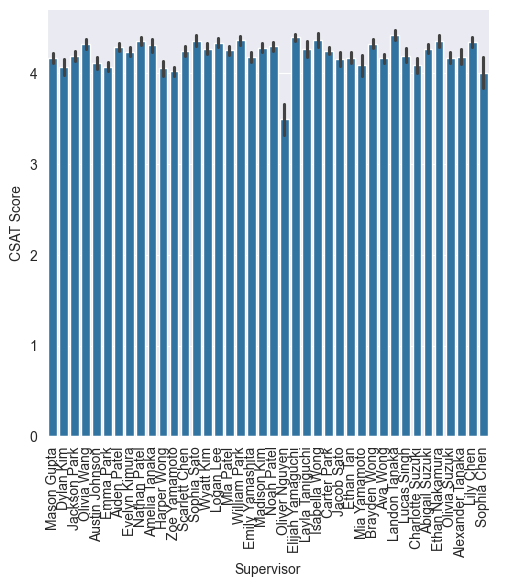

In [62]:
count = CS_data['Supervisor'].value_counts()
sns.barplot(x=count.index.values, y=count.values)
plt.xticks(rotation=90)
plt.show()

sns.catplot(data=CS_data, x='Supervisor', y='CSAT Score', kind='bar')
plt.xticks(rotation=90)
plt.show()


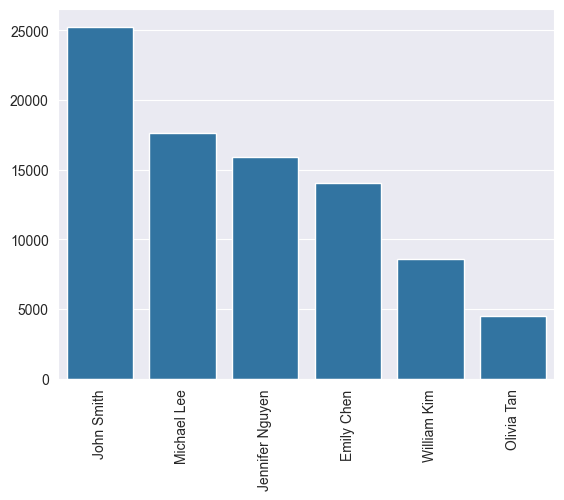

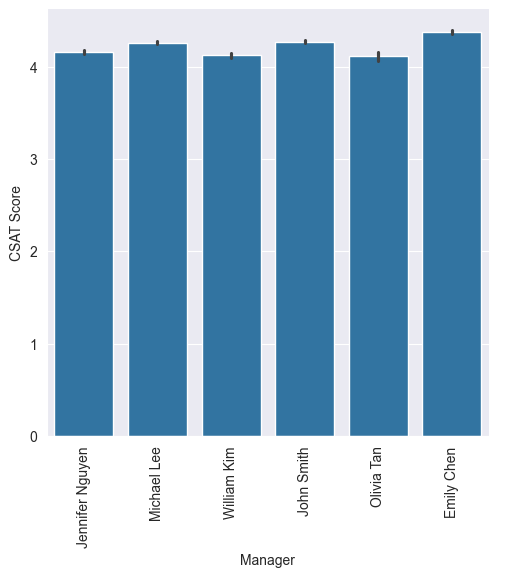

In [63]:
count = CS_data['Manager'].value_counts()
sns.barplot(x=count.index.values, y=count.values)
plt.xticks(rotation=90)
plt.show()

sns.catplot(data=CS_data, x='Manager', y='CSAT Score', kind='bar')
plt.xticks(rotation=90)
plt.show()


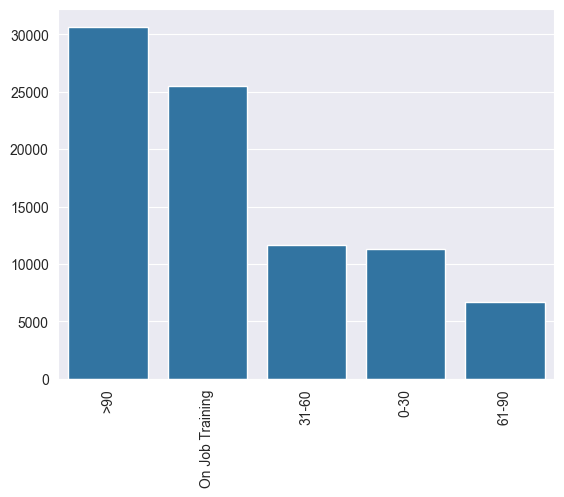

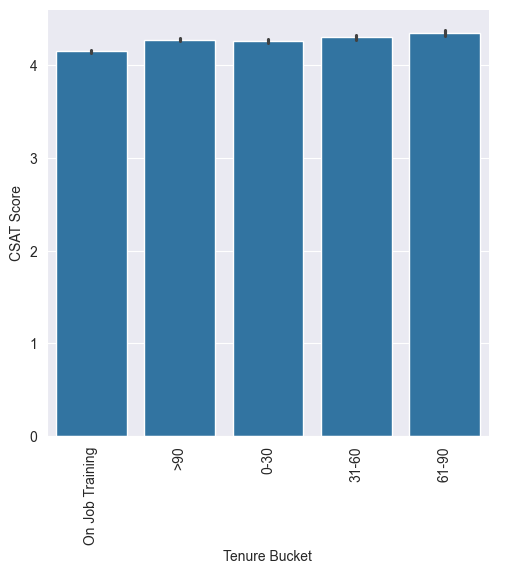

In [64]:
count = CS_data['Tenure Bucket'].value_counts()
sns.barplot(x=count.index.values, y=count.values)
plt.xticks(rotation=90)
plt.show()

sns.catplot(data=CS_data, x='Tenure Bucket', y='CSAT Score', kind='bar')
plt.xticks(rotation=90)
plt.show()


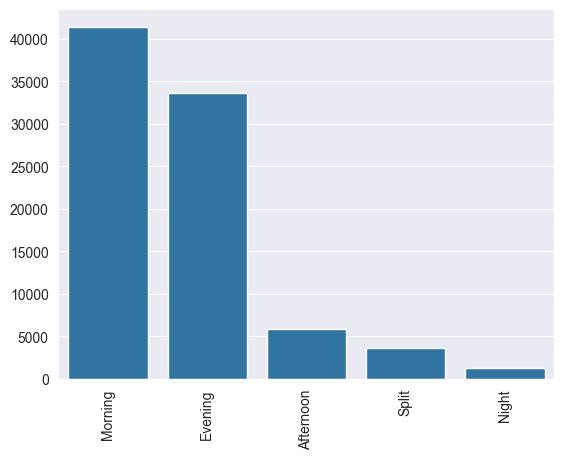

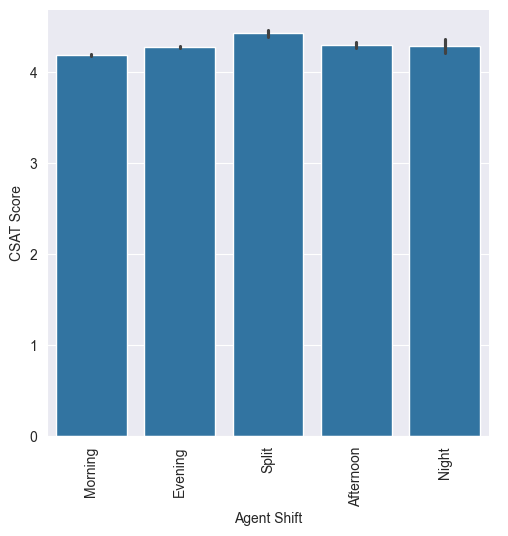

In [65]:
count = CS_data['Agent Shift'].value_counts()
sns.barplot(x=count.index.values, y=count.values)
plt.xticks(rotation=90)
plt.show()

sns.catplot(data=CS_data, x='Agent Shift', y='CSAT Score', kind='bar')
plt.xticks(rotation=90)
plt.show()


In [66]:
CS_data['Customer Remarks New'] = (CS_data['Customer Remarks'].str.len()> 3).astype(int)
CS_data['Is_order'] = (CS_data['Order_id'].isna()).astype(int)
CS_data.loc[~CS_data["Sub-category"].isin([
    "Reverse Pickup Enquiry", "Return request", "Delayed", "Order status enquiry",
    "Installation/demo", "Fraudulent User", "Product Specific Information"
    ]), "Sub-category"] = "Other"
CS_data['Agent_count'] = CS_data.groupby(['Agent_name'])['Agent_name'].transform('count')
CS_data['Sups_no_agents'] = CS_data.groupby(['Supervisor'])['Agent_name'].transform('nunique')
CS_data.head()


,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,...,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Customer Remarks New,Is_order,Agent_count,Sups_no_agents
Unique id,,,,,,,,,,,,,,,,,,,,,
7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Other,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,...,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,0,0,42,41
b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,...,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,0,0,32,17
200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,...,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,0,0,35,46
eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,...,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,0,0,48,28
ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Other,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,...,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,0,0,124,29


In [67]:
CS_data['Product_category'] = CS_data['Product_category'].fillna('unknown')
CS_data['connected_handling_time'] = CS_data['connected_handling_time'].fillna('0')

In [68]:
from sklearn.preprocessing import LabelEncoder

titanic = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML5.3%20categorical%20features/data/titanic.csv', index_col=0)

LE_sex = LabelEncoder()

titanic.Sex = LE_sex.fit_transform(titanic.Sex)

titanic.Pclass = titanic.Pclass.replace({
    'first': 1,
    'second': 2,
    'third': 3
})

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


In [69]:
from sklearn.preprocessing import OneHotEncoder

OH_embarked = OneHotEncoder(sparse_output=False)
OH_embarked.fit_transform(titanic[['Embarked']])

dummies = pd.DataFrame(OH_embarked.fit_transform(titanic[['Embarked']]), columns=OH_embarked.get_feature_names_out(['Embarked']), index=titanic.index)

titanic_dummies = pd.concat([titanic, dummies]).drop(['Embarked'], axis=1)

In [70]:
CS_dropped = CS_data.drop([
    "Sub-category",
    "Customer Remarks",
    "Customer_City",
    "Agent_name",
    "Supervisor",
    "Order_id",
    "order_date_time",
    "Issue_reported at",
    "issue_responded",
    "Survey_response_Date",
    "Item_price",

], axis=1)

CS_dummies = pd.get_dummies(CS_dropped)


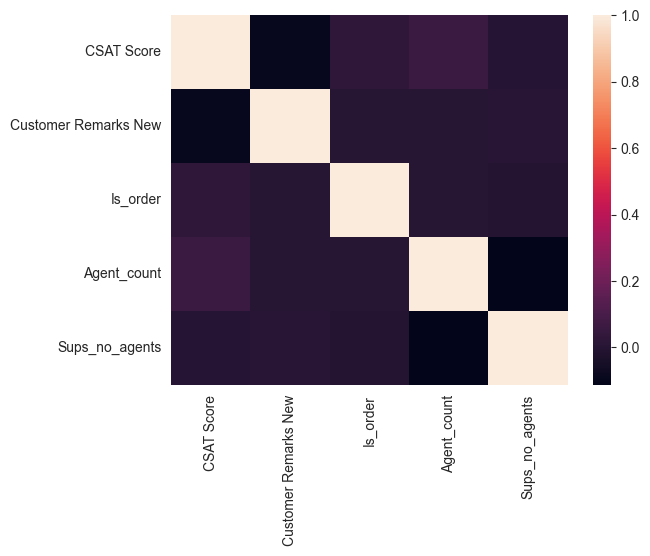

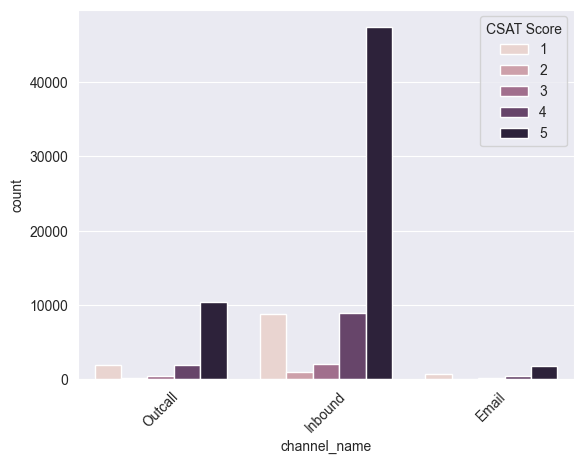

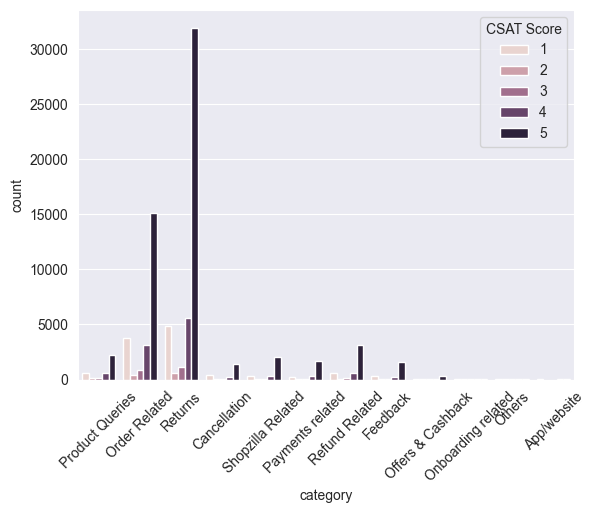

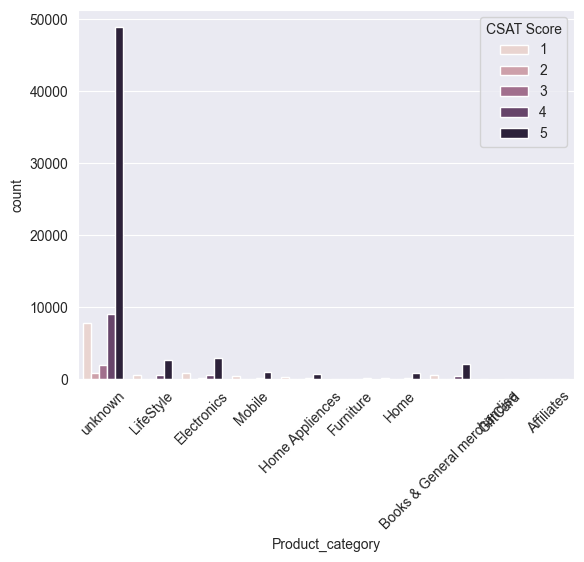

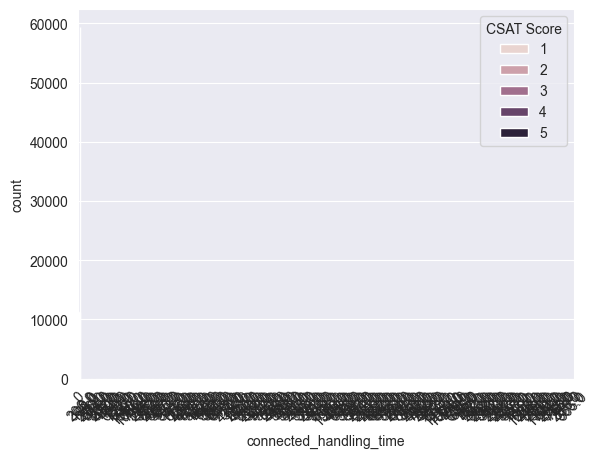

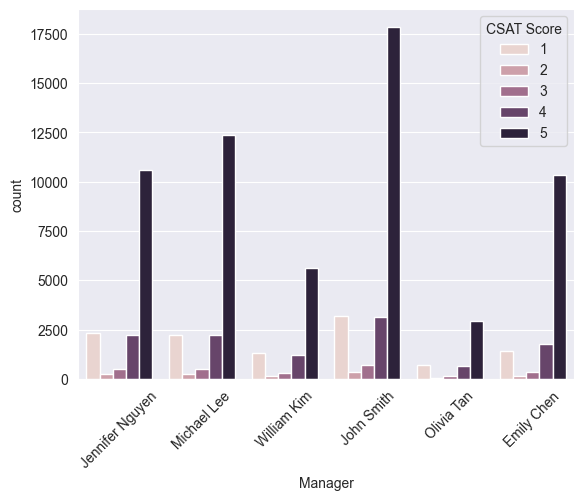

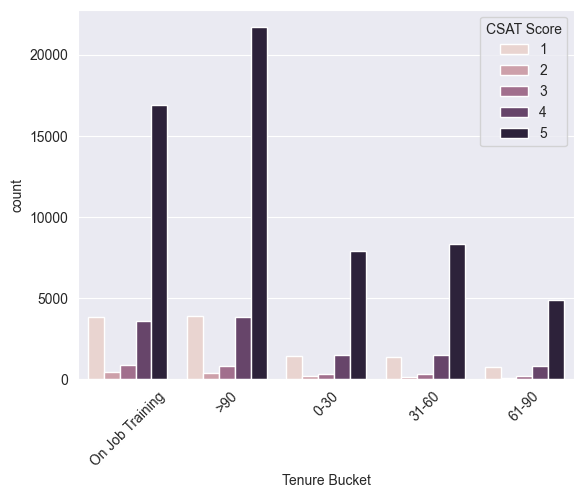

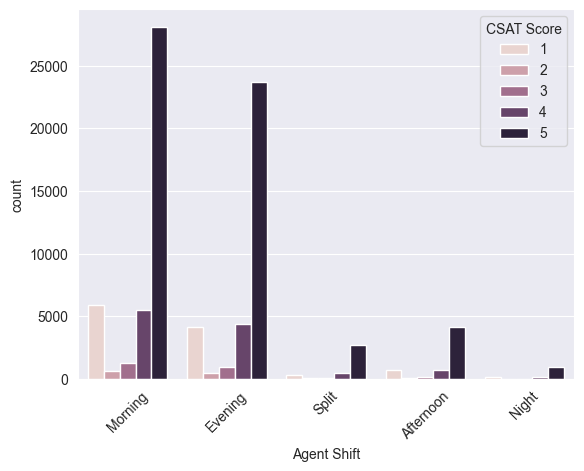

In [71]:
sns.heatmap(CS_dropped.corr(numeric_only=True))
plt.show()

for cols in CS_dropped.select_dtypes(exclude='number').columns:
    sns.countplot(data=CS_dropped, x=cols, hue='CSAT Score')
    plt.xticks(rotation=45)
    plt.show()

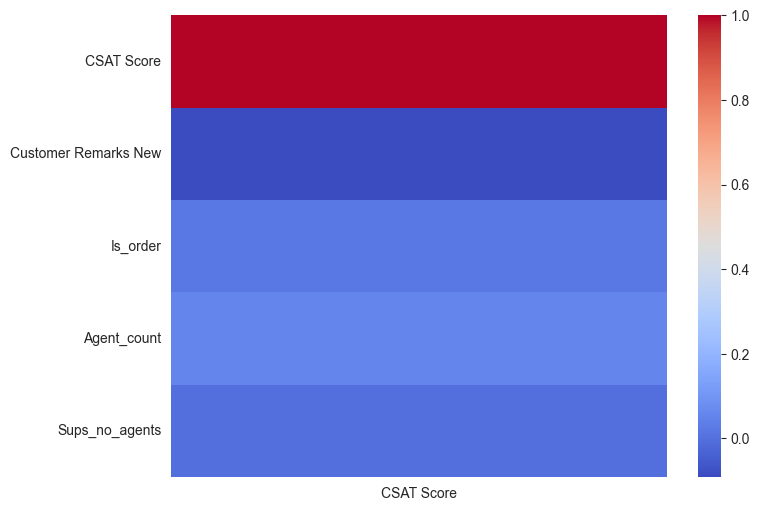

In [72]:
plt.figure(figsize=(8, 6))

target_corr = CS_dropped.corr(numeric_only=True)[["CSAT Score"]]

sns.heatmap(
    target_corr,
    cmap="coolwarm",
)

plt.show()

In [73]:
# for col in CS_data.select_dtypes(include='object').columns:
#     if col == "CSAT Score":
#         continue
#
#     pivot = pd.crosstab(CS_data[col], CS_data["CSAT Score"], normalize="index")
#
#     sns.heatmap(pivot, annot=True, cmap="coolwarm")
#
#     plt.show()

0.6948095033000803


C:\Users\Artem\AppData\Local\Temp\ipykernel_32956\467994084.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include='object').columns:


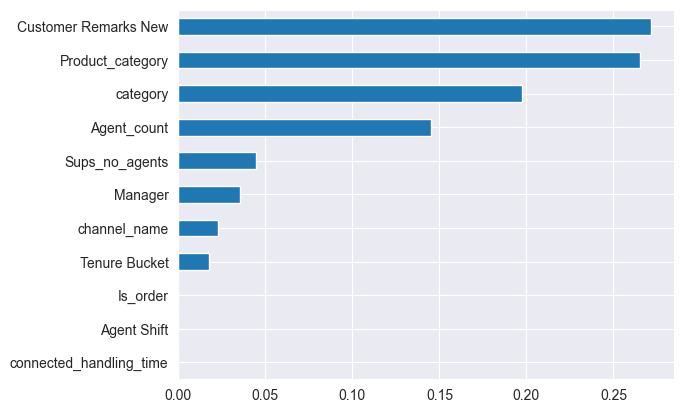

In [74]:
from sklearn.tree import DecisionTreeClassifier

data = CS_dropped.copy()

for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

X = data.drop('CSAT Score', axis=1)
y = data['CSAT Score']

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X, y)

print(model.score(X, y))

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh")
plt.show()

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)



<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    str    
 4   Sex          891 non-null    int64  
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), object(1), str(4)
memory usage: 83.7+ KB
None


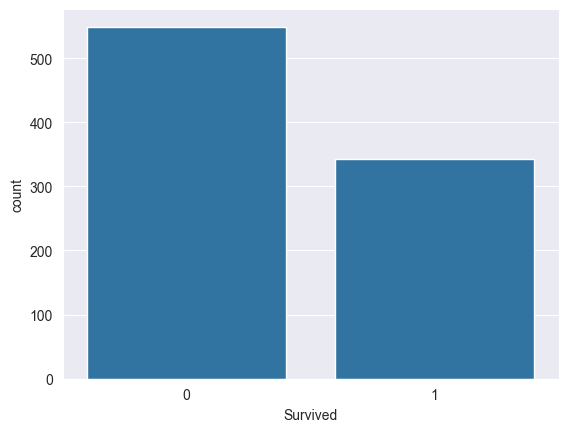

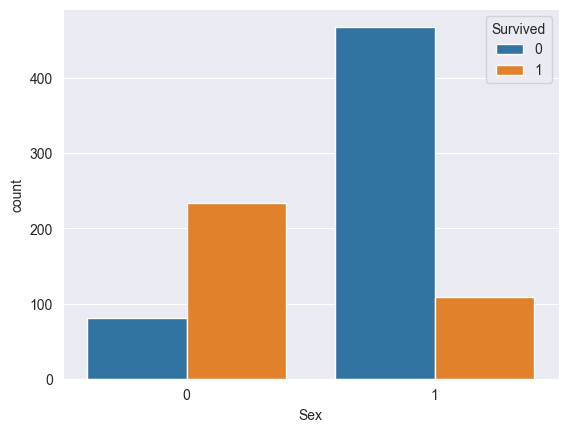

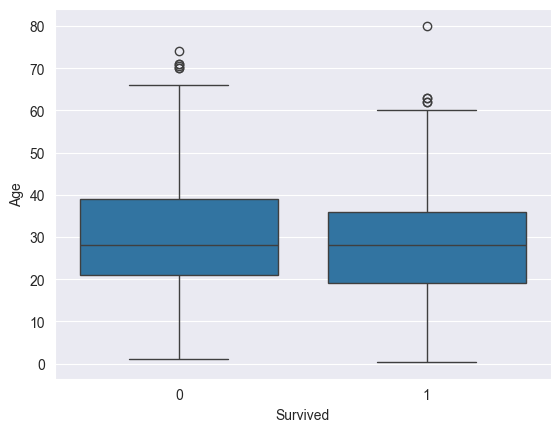

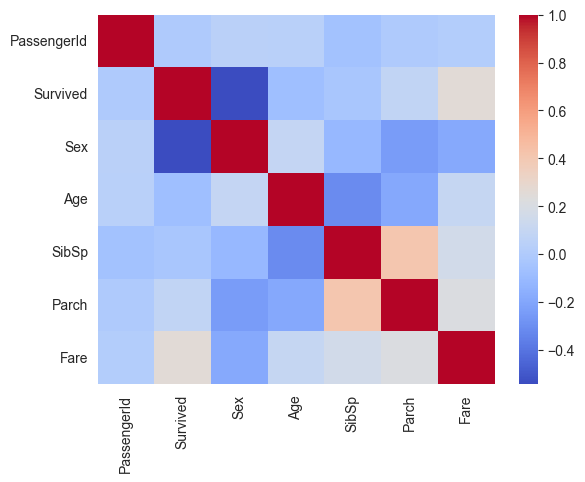

In [76]:
print(titanic.info())
sns.countplot(x="Survived", data=titanic)
plt.show()
sns.countplot(x="Sex", hue='Survived', data=titanic)
plt.show()
sns.boxplot(x="Survived", y='Age', data=titanic)
plt.show()
sns.heatmap(titanic.corr(numeric_only=True), cmap="coolwarm")
plt.show()

In [77]:
titanic["Age"].fillna(titanic["Age"].median(), inplace=True)
titanic['Embarked'].fillna(titanic['Embarked'].mode()[0], inplace=True)

titanic = pd.get_dummies(titanic, drop_first=True)
titanic.head()

C:\Users\Artem\AppData\Local\Temp\ipykernel_32956\1688241958.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic["Age"].fillna(titanic["Age"].median(), inplace=True)
C:\Users\Artem\AppData\Local\Temp\ipykernel_32956\1688241958.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chaine

,PassengerId,Survived,Sex,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,"Name_Abbott, Mr. Rossmore Edward",...,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_Q,Embarked_S
0,1,0,1,22.0,1,0,7.2500,False,True,False,...,False,False,False,False,False,False,False,False,False,True
1,2,1,0,38.0,1,0,71.2833,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,1,0,26.0,0,0,7.9250,False,True,False,...,False,False,False,False,False,False,False,False,False,True
3,4,1,0,35.0,1,0,53.1000,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,5,0,1,35.0,0,0,8.0500,False,True,False,...,False,False,False,False,False,False,False,False,False,True


In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(X_train, X_test, y_train, y_test):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))

data = CS_dropped.copy()

X = data.drop('CSAT Score', axis=1)
y = data['CSAT Score']
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


raw = evaluate(X_train, X_test, y_train, y_test)
print(f'Raw {raw}')

scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

score_scaler = evaluate(X_train_scaler, X_test_scaler, y_train, y_test)

print(f'Scaled {score_scaler}')

C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Raw 0.6947968804562915
Scaled 0.6926434640903271


In [90]:
from sklearn.compose import ColumnTransformer

data = CS_dropped.copy()

X = data.drop('CSAT Score', axis=1)
y = data['CSAT Score']


num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include='object').columns
X[cat_cols] = X[cat_cols].astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
])

pipeline.fit(X_train, y_train)

C:\Users\Artem\AppData\Local\Temp\ipykernel_32956\2182416231.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma